In [ ]:
# ==============================================================================
# STEP 1: RESOLVING DEPENDENCY CONFLICTS (MODERN STACK)
# ==============================================================================
print("Syncing Quantum ML environment with Kaggle 2026 standards...")

# 1. We upgrade PennyLane to the latest version (0.39+) which supports NumPy 2.0
# 2. We align TensorFlow with the pre-installed Kaggle packages (2.19.0)
# 3. We ensure ml_dtypes is at least 0.5.0 for JAX compatibility
!pip install --upgrade "pennylane>=0.39.0" "ml_dtypes>=0.5.0" tensorflow==2.19.0 tensorflow-text==2.19.0 --quiet

print("\n✓ Environment synced. Please RESTART SESSION now.")

In [2]:
import numpy as np
import pennylane as qml
import tensorflow as tf

# Check compatibility
print(f"✓ PennyLane: {qml.__version__} (NumPy 2.0 compatible)")
print(f"✓ TensorFlow: {tf.__version__}")
print(f"✓ NumPy: {np.__version__}")

# Quick check to ensure JAX (PennyLane's backend) isn't crying
try:
    import jax
    print(f"✓ JAX: {jax.__version__}")
except Exception as e:
    print(f"✗ JAX issue: {e}")

✓ PennyLane: 0.44.1 (NumPy 2.0 compatible)
✓ TensorFlow: 2.19.0
✓ NumPy: 1.26.4
✓ JAX: 0.7.2


In [3]:
# ==============================================================================
# STEP 2: DATA LOADING (KAGGE INPUT PATHS)
# ==============================================================================

DATASET_PATH = '/kaggle/input/datasets/promitsarker/marsterraindataset'
CLASS_NAMES = ['boulder', 'dusty', 'flat_terrain', 'hills_or_ridge', 'rocky', 'rover']
IMG_SIZE = (64, 64)

def load_mars_data():
    print(f"Loading data from: {DATASET_PATH}...")
    images, labels = [], []
    
    # Standard Kaggle/Common dataset split structure check
    # If /train exists, we use it; otherwise, we walk the root
    train_root = os.path.join(DATASET_PATH, 'train') if os.path.exists(os.path.join(DATASET_PATH, 'train')) else DATASET_PATH

    for idx, class_name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(train_root, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: Class directory {class_dir} not found. Skipping.")
            continue
        
        files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"  - Found {len(files)} images for '{class_name}'")
        
        for f in files:
            img_path = os.path.join(class_dir, f)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                img = cv2.resize(img, IMG_SIZE)
                images.append(img)
                labels.append(idx)
                
    return np.array(images) / 255.0, np.array(labels)

In [17]:
# ==============================================================================
# STEP 3: OPTIMIZED MODELS (AMPLITUDE ENCODING UPDATE)
# ==============================================================================

import os
import cv2
import numpy as np
import pennylane as qml
import tensorflow as tf
from tensorflow.keras import layers, models

# Ensure consistent float types for PennyLane/TensorFlow integration
tf.keras.backend.set_floatx('float32')

# --- 1. DATA LOADER (Unchanged) ---
def load_mars_data(base_path='/kaggle/input/datasets/promitsarker/marsterraindataset/train', img_size=64):
    classes = ['boulder', 'dusty', 'flat_terrain', 'hills_or_ridge', 'rocky', 'rover']
    images = []
    labels = []
    
    print(f"Reading images from {base_path}...")
    for label_idx, class_name in enumerate(classes):
        class_path = os.path.join(base_path, class_name)
        if not os.path.isdir(class_path): continue
        
        for img_name in os.listdir(class_path):
            try:
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (img_size, img_size))
                images.append(img)
                labels.append(label_idx)
            except Exception:
                continue 
                
    return np.array(images) / 255.0, np.array(labels)

# --- 2. QUANTUM NODE (Updated for Amplitude Encoding) ---
n_qubits = 4
n_features = 2**n_qubits # 16 features for 4 qubits
n_layers = 3 
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="tf")
def q_node(inputs, weights):
    # AmplitudeEmbedding packs 16 classical features into 4 qubits
    qml.AmplitudeEmbedding(features=inputs, wires=range(n_qubits), normalize=True)
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# --- 3. CUSTOM KERAS LAYER (Includes our previous Autoray fixes) ---
# --- 3. CUSTOM KERAS LAYER (Updated to silence complex128 warnings) ---
class CustomQuantumLayer(layers.Layer):
    def __init__(self, n_qubits, n_layers, **kwargs):
        super().__init__(**kwargs)
        self.n_qubits = n_qubits
        self.n_layers = n_layers

    def build(self, input_shape):
        self.q_weights = self.add_weight(
            shape=(self.n_layers, self.n_qubits),
            initializer="random_normal",
            trainable=True,
            name="q_weights"
        )
        super().build(input_shape)

    def call(self, inputs):
        tf_weights = tf.convert_to_tensor(self.q_weights, dtype=tf.float32)
        return tf.map_fn(
            # FIX 1: Explicitly cast 'x' to complex128 to stop TensorFlow from panicking
            lambda x: tf.cast(tf.math.real(tf.stack(q_node(tf.cast(x, tf.complex128), tf_weights))), tf.float32), 
            inputs,
            fn_output_signature=tf.TensorSpec(shape=(self.n_qubits,), dtype=tf.float32)
        )

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.n_qubits)

# --- 4. HYBRID MODEL (Updated to prevent NaN crashes) ---
def create_hybrid_model():
    model = models.Sequential([
        layers.Input(shape=(64, 64, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'), 
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        
        # FIX 2: Changed from 'relu' to 'tanh' to prevent the 0-vector division by zero!
        layers.Dense(n_features, activation='tanh'), 
        
        CustomQuantumLayer(n_qubits=n_qubits, n_layers=n_layers),                                     
        
        layers.Dense(6, activation='softmax')  
    ])
    return model

print("✓ STEP 3 Defined: Anti-NaN measures engaged!")


✓ STEP 3 Defined: Anti-NaN measures engaged!


In [18]:
# ==============================================================================
# STEP 4: TRAINING EXECUTION
# ==============================================================================

try:
    print("🚀 Initializing Mars Terrain Mission...")
    
    # Define the root dataset path
    DATA_ROOT = '/kaggle/input/datasets/promitsarker/marsterraindataset'
    
    # 1. Load Data using the correct 'base_path' argument
    X_train, y_train = load_mars_data(base_path=f'{DATA_ROOT}/train')
    X_val, y_val = load_mars_data(base_path=f'{DATA_ROOT}/valid')
    
    if len(X_train) == 0:
        raise ValueError("No images loaded. Please check the dataset path spelling!")

    # 2. Prepare Shapes
    # IMG_SIZE is 64 based on our load_mars_data default
    IMG_SIZE = 64 
    X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    X_val = X_val.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    
    print(f"\n📊 Stats: {len(X_train)} Train / {len(X_val)} Val")
    
    # 3. Model Setup
    model = create_hybrid_model()
    model.compile(
        optimizer='adam', 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )
    
    # 4. Train
    # 4. Train
    print("\n🛰️ Starting Training...")
    history = model.fit( # <--- Add "history =" here
        X_train, y_train, 
        epochs=15,       # (Bump this up so your graphs look good!)
        batch_size=32, 
        validation_data=(X_val, y_val)
    )
    
    print("\n✅ Mission Accomplished!")

except Exception as e:
    print(f"\n❌ Error: {e}")

🚀 Initializing Mars Terrain Mission...
Reading images from /kaggle/input/datasets/promitsarker/marsterraindataset/train...
Reading images from /kaggle/input/datasets/promitsarker/marsterraindataset/valid...

📊 Stats: 2057 Train / 515 Val

🛰️ Starting Training...
Epoch 1/15


/tmp/ipykernel_323/283113810.py:72: PennyLaneDeprecationWarning: Support for the TensorFlow interface is deprecated and will be removed in v0.44. Future versions of PennyLane are not guaranteed to work with TensorFlow. Please migrate your workflows to JAX or Pytorch to benefit from enhanced support and features.
  lambda x: tf.cast(tf.math.real(tf.stack(q_node(tf.cast(x, tf.complex128), tf_weights))), tf.float32),


65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.2202 - loss: 1.7601 - val_accuracy: 0.3437 - val_loss: 1.6492
Epoch 2/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3687 - loss: 1.5790 - val_accuracy: 0.3903 - val_loss: 1.5174
Epoch 3/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4149 - loss: 1.4676 - val_accuracy: 0.4563 - val_loss: 1.4292
Epoch 4/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5163 - loss: 1.3669 - val_accuracy: 0.4990 - val_loss: 1.4014
Epoch 5/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5800 - loss: 1.2846 - val_accuracy: 0.4932 - val_loss: 1.3748
Epoch 6/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6386 - loss: 1.1939 - val_accuracy: 0.5068 - val_loss: 1.3439
Epoch 7/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6807 - loss: 1.0893 - val_accuracy: 0.5262 - val_loss: 1.2835
Epoch 8/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7537 - loss: 0.9842 - val_accuracy: 0.5262 - val_loss: 

📊 Generating Mission Reports...


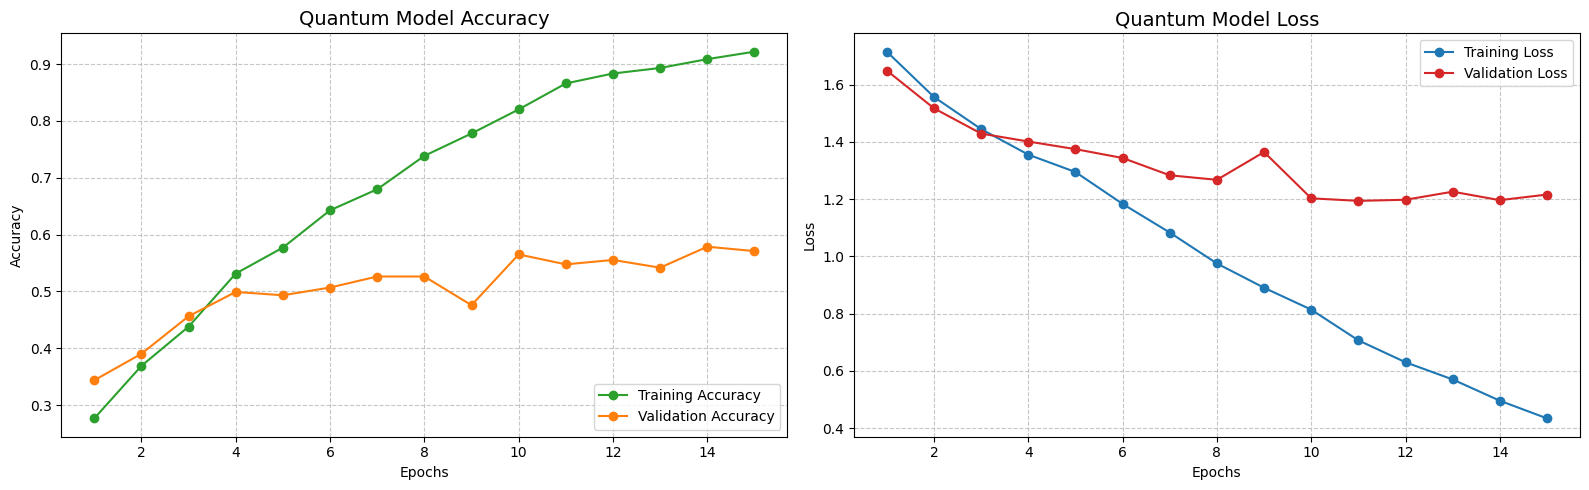


🔬 Analyzing Validation Data...


/tmp/ipykernel_323/283113810.py:72: PennyLaneDeprecationWarning: Support for the TensorFlow interface is deprecated and will be removed in v0.44. Future versions of PennyLane are not guaranteed to work with TensorFlow. Please migrate your workflows to JAX or Pytorch to benefit from enhanced support and features.
  lambda x: tf.cast(tf.math.real(tf.stack(q_node(tf.cast(x, tf.complex128), tf_weights))), tf.float32),


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step

📝 Detailed Classification Report:
-------------------------------------------------------
                precision    recall  f1-score   support

       boulder       0.45      0.43      0.44        90
         dusty       0.80      0.58      0.67        76
  flat_terrain       0.44      0.55      0.49       102
hills_or_ridge       0.73      0.75      0.74        83
         rocky       0.46      0.46      0.46       106
         rover       0.80      0.76      0.78        58

      accuracy                           0.57       515
     macro avg       0.61      0.59      0.60       515
  weighted avg       0.59      0.57      0.57       515



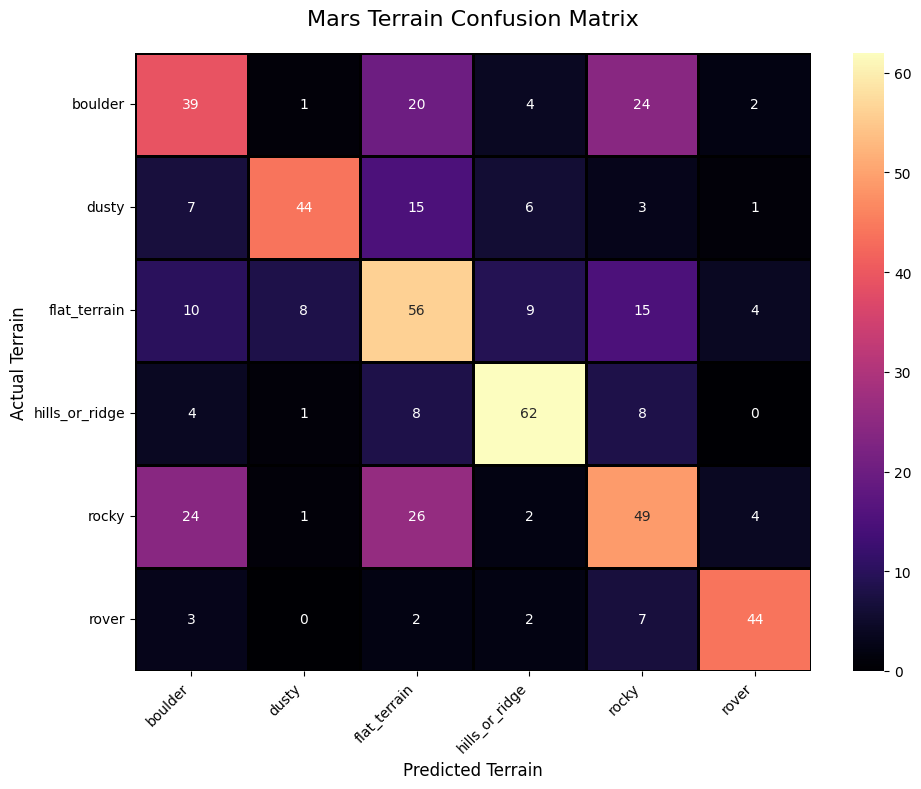

In [19]:
# %% [code]
# ==============================================================================
# STEP 5: EVALUATION & VISUALIZATION
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("📊 Generating Mission Reports...")

# --- 1. PLOT ACCURACY & LOSS CURVES ---
try:
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Accuracy Plot
    axes[0].plot(epochs_range, acc, label='Training Accuracy', marker='o', color='#2ca02c')
    axes[0].plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='#ff7f0e')
    axes[0].set_title('Quantum Model Accuracy', fontsize=14)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Loss Plot
    axes[1].plot(epochs_range, loss, label='Training Loss', marker='o', color='#1f77b4')
    axes[1].plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='#d62728')
    axes[1].set_title('Quantum Model Loss', fontsize=14)
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

except NameError:
    print("⚠️ Error: 'history' variable not found. Make sure you added 'history = model.fit(...)' in Step 4!")

# --- 2. GENERATE PREDICTIONS ---
print("\n🔬 Analyzing Validation Data...")
# Get the model's raw probability outputs
y_pred_probs = model.predict(X_val)
# Convert probabilities to class labels (0 to 5)
y_pred = np.argmax(y_pred_probs, axis=1)

classes = ['boulder', 'dusty', 'flat_terrain', 'hills_or_ridge', 'rocky', 'rover']

# --- 3. CLASSIFICATION REPORT ---
print("\n📝 Detailed Classification Report:")
print("-" * 55)
print(classification_report(y_val, y_pred, target_names=classes))

# --- 4. CONFUSION MATRIX ---
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
            xticklabels=classes, yticklabels=classes,
            linewidths=1, linecolor='black')

plt.title('Mars Terrain Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual Terrain', fontsize=12)
plt.xlabel('Predicted Terrain', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()